# LDPC vs GRAND as Information Reconciliation for BB84 — Research Log

**Research question.** For BB84 sifted keys produced by our Qiskit-Aer simulator, where (in the
block-length × QBER plane) does GRAND (noise-guessing decoding) outperform a rate-adaptive LDPC
baseline as the information-reconciliation step — and is there a clear *crossover point*?

**Scope & honesty rules.**
- This is an *experimental comparison*, not a new decoding algorithm.
- A clear crossover is a useful finding; an ambiguous or negative result is reported as-is.
- The LDPC baseline is deliberately **rate-adaptive** (code rate chosen from the estimated QBER
  using pre-characterised code performance). A fixed-rate LDPC strawman would flatter GRAND.
- Any result that looks too clean gets flagged and sanity-checked before we build on it.

**Stages.** 1) Setup & calibration (this section) → 2) Spike experiment on a small grid →
3) Expand the grid *or* report the honest negative, depending on what the spike shows.

*Branch: `error-analysis-ldpc-vs-grand`. Supporting library: [`reconciliation.py`](reconciliation.py).*

## 1. Setup

**What the existing simulator provides** (`bb84_core.py`, `bb84_noise.py`, `bb84_runner.py`):
Alice/Bob/Eve parties, five Aer-backed noise models, sifting and QBER estimation with Wilson CIs.
The stock runner submits **one Aer job per qubit**, which is far too slow for the ~10⁵-bit key
pools we need, so `reconciliation.generate_sifted_pool` reuses the *same* `Alice`/`Bob` classes and
the *same* `QuantumChannel` noise model but batches all single-qubit circuits into a few large Aer
jobs (~100× faster, statistically identical channel).

**What this study adds** (`reconciliation.py`):
- A common **syndrome-based reconciliation protocol**: Alice publishes `s_A = H·x (mod 2)`
  (m bits leaked); Bob solves for the most likely error vector `e` with `H·e = s_A ⊕ H·y`.
  Both methods use this same protocol, so **leakage accounting is identical: leak = m**.
- **LDPC**: sparse regular parity-check matrices built with `pyldpc` (`d_v ≥ 3`; `d_v = 2`
  cycle codes were tried and fail BP badly), decoded with syndrome-target sum-product belief
  propagation. `pyldpc`'s own decoder targets AWGN codeword transmission, which is why the BP
  decoder here is custom — but code *construction* comes from `pyldpc`.
- **GRAND**: dense random parity-check matrix (the natural code family for GRAND — random linear
  codes are near-ML-optimal at short lengths), error patterns enumerated in increasing
  Hamming-weight order (exactly ML order for a BSC with p < ½), abandoning after a fixed guess
  budget.
- Note: the repo's existing `bb84_grand.py` validates candidates against **Alice's key itself**
  ("oracle" mode). That is fine for demonstrating the guessing mechanics but is not a runnable
  protocol — Bob doesn't have Alice's key. Here GRAND is put on the same syndrome footing as LDPC.

In [1]:
import sys, json, time, math, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import qiskit, qiskit_aer

sys.path.insert(0, str(Path.cwd()))
import reconciliation as rc
from reconciliation import (generate_sifted_pool, LDPCReconciler, GRANDReconciler,
                            h2, result_row, _grand_search)

RESULTS = Path("results_error_analysis"); RESULTS.mkdir(exist_ok=True)
SEED_CAL, SEED_POOL, SEED_CODE = 11_000, 20_260_718, 0

print("python", platform.python_version(), "| qiskit", qiskit.__version__,
      "| qiskit-aer", qiskit_aer.__version__)
print("numpy", np.__version__, "| pandas", pd.__version__)

python 3.13.14 | qiskit 2.5.0 | qiskit-aer 0.17.2
numpy 2.4.6 | pandas 3.0.3


## 2. Channel calibration: depolarising strength → QBER

The simulator attaches depolarising noise **per gate** (`x`, `h`, `id`), and the number of gates
depends on the bit/basis combination (bit 0 in the rectilinear basis uses *no* gates at all). So
`depolar_prob` is not the QBER — we calibrate the mapping empirically and pick the
`depolar_prob` values that hit our three target QBER levels (2 %, 6 %, 10 %).

 depolar_prob     qber
         0.00 0.000000
         0.02 0.015667
         0.05 0.036167
         0.08 0.050333
         0.11 0.073500
         0.14 0.093167
         0.18 0.114667 

target  depolar_prob  measured_qber
    2%        0.0263         0.0182
    6%        0.0925         0.0683
   10%        0.1527         0.1025


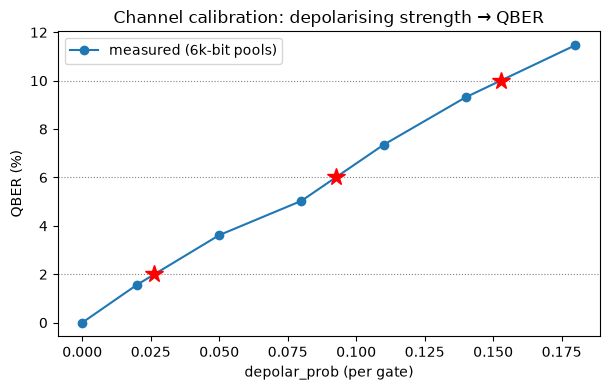

In [2]:
depolar_grid = [0.00, 0.02, 0.05, 0.08, 0.11, 0.14, 0.18]
cal_rows = []
for i, dp in enumerate(depolar_grid):
    pool = generate_sifted_pool(6000, depolar_prob=dp, seed=SEED_CAL + i)
    cal_rows.append({"depolar_prob": dp, "qber": pool.true_qber})
cal = pd.DataFrame(cal_rows)

TARGET_QBERS = {"2%": 0.02, "6%": 0.06, "10%": 0.10}
depolar_for = {lab: float(np.interp(q, cal.qber, cal.depolar_prob))
               for lab, q in TARGET_QBERS.items()}

# Verify the interpolated settings on fresh pools (different seeds)
ver_rows = []
for j, (lab, dp) in enumerate(depolar_for.items()):
    pool = generate_sifted_pool(8000, depolar_prob=dp, seed=SEED_CAL + 100 + j)
    ver_rows.append({"target": lab, "depolar_prob": round(dp, 4),
                     "measured_qber": round(pool.true_qber, 4)})
ver = pd.DataFrame(ver_rows)
print(cal.to_string(index=False), "\n")
print(ver.to_string(index=False))

fig, ax = plt.subplots(figsize=(6.2, 4))
ax.plot(cal.depolar_prob, cal.qber * 100, "o-", label="measured (6k-bit pools)")
for lab, q in TARGET_QBERS.items():
    ax.axhline(q * 100, ls=":", c="grey", lw=0.8)
    ax.plot(depolar_for[lab], q * 100, "r*", ms=13)
ax.set_xlabel("depolar_prob (per gate)"); ax.set_ylabel("QBER (%)")
ax.set_title("Channel calibration: depolarising strength → QBER")
ax.legend(); fig.tight_layout()

### Error-structure sanity check (is the channel really a BSC?)

Both decoders model the sifted-key channel as a binary symmetric channel (BSC) with a single
crossover probability. Because gate count varies with the bit/basis combination, the *true*
channel is a mixture of BSCs. We check how uneven the error rates are and whether errors are
serially correlated — both decoders face the same channel either way, so the *comparison* stays
fair, but absolute FERs may deviate slightly from single-BSC theory. Flagged here so nothing
downstream looks "too clean".

In [3]:
pool6 = generate_sifted_pool(20000, depolar_prob=depolar_for["6%"], seed=SEED_CAL + 500)
err = (pool6.alice_bits != pool6.bob_bits).astype(int)

rows = []
for basis in (0, 1):
    for bit in (0, 1):
        m = (pool6.alice_bases == basis) & (pool6.bit_values == bit)
        rows.append({"basis": ["rect(+)", "diag(x)"][basis], "bit": bit,
                     "n": int(m.sum()), "err_rate": round(float(err[m].mean()), 4)})
print(pd.DataFrame(rows).to_string(index=False))
lag1 = np.corrcoef(err[:-1], err[1:])[0, 1]
print(f"\noverall QBER {err.mean():.4f} | lag-1 autocorrelation of errors {lag1:+.4f}")

  basis  bit    n  err_rate
rect(+)    0 4900    0.0000
rect(+)    1 5043    0.0470
diag(x)    0 4976    0.0886
diag(x)    1 5081    0.1277

overall QBER 0.0664 | lag-1 autocorrelation of errors -0.0033


## 3. The two reconciliation methods, and what makes the comparison fair

| | LDPC (baseline) | GRAND (challenger) |
|---|---|---|
| Code | regular sparse H from `pyldpc`, ladder of syndrome rates m/n ∈ [0.15 … 0.875] | dense random H, any m |
| Decoder | syndrome-target sum-product BP (≤120 iters) | weight-ordered guessing, budget 2×10⁶ guesses |
| Rate adaptation | code with **max expected net key** (1−FER(p̂))·(n−m)/n, using FER curves measured offline per code (next cell) | m = ⌈n·h₂(p̂)⌉ + 16 safety bits (near Slepian–Wolf optimum; the 16 bits keep syndrome-collision "undetected error" probability ~2⁻¹⁶) |
| Leakage | m rows of H | m rows of H |

**Metrics per block** — `correct` (corrected key equals Alice's), `undetected_error` (decoder
*claims* success but key is wrong — in deployment this is what hash verification catches, and it
is security-relevant), `net_key_fraction` = (n−m)/n if correct else 0, wall-clock `time_s`, and
`work_units` (BP iterations / GRAND guesses).

**Both methods receive the same information**: the same blocks (paired trials), and the same
pool-level QBER estimate p̂ from a sacrificed 10 % sample — nobody sees ground truth.

**Pre-registered decision rule** (written *before* running the spike): in each (n, QBER) cell the
primary metric is mean net key fraction; a method "wins" the cell if the paired-bootstrap 95 % CI
of the difference excludes zero. A *crossover* exists if the winner flips along the block-length
axis with both sides significant. Decode time is a secondary axis, reported separately — GRAND
results are always "GRAND at a 2×10⁶-guess budget", since abandonment is budget-dependent.

In [4]:
# Offline LDPC code-library characterisation: FER curves per (n, rate) on synthetic
# BSC data with seeds disjoint from every evaluation seed. Cached to JSON.
BLOCK_LENGTHS = [64, 200, 1000, 4000]
ldpc = {}
cal_path = RESULTS / "ldpc_fer_curves.json"
cache = json.loads(cal_path.read_text()) if cal_path.exists() else {}

for n in BLOCK_LENGTHS:
    lr = LDPCReconciler(n, seed=SEED_CODE)
    if str(n) in cache:
        lr.fer_curves = {float(r): [tuple(pt) for pt in c] for r, c in cache[str(n)].items()}
        src = "cache"
    else:
        t0 = time.perf_counter()
        lr.calibrate(trials=12, seed=777_000 + n)
        cache[str(n)] = {str(r): c for r, c in lr.fer_curves.items()}
        cal_path.write_text(json.dumps(cache))
        src = f"calibrated in {time.perf_counter() - t0:.0f}s"
    ldpc[n] = lr
    print(f"n={n:5d} ({src}):  rates {[round(r, 3) for r in lr.available_rates]}")

# Usable-region summary: highest crossover probability with interpolated FER <= 10%
summ = []
for n, lr in ldpc.items():
    for rate in lr.available_rates:
        ps = np.linspace(1e-4, 0.20, 400)
        ok = [p for p in ps if lr._fer_at(rate, p) <= 0.10]
        summ.append({"n": n, "rate": rate, "p_max_fer10": round(max(ok), 4) if ok else 0.0})
summ = pd.DataFrame(summ).pivot(index="rate", columns="n", values="p_max_fer10")
print("\nMax QBER each code handles at FER<=10% (0 = unusable):")
print(summ.to_string())

n=   64 (cache):  rates [0.188, 0.375, 0.5, 0.625, 0.75, 0.875]
n=  200 (cache):  rates [0.15, 0.2, 0.25, 0.3, 0.375, 0.4, 0.5, 0.6, 0.625, 0.7, 0.75, 0.875]
n= 1000 (cache):  rates [0.15, 0.2, 0.25, 0.3, 0.375, 0.4, 0.5, 0.6, 0.625, 0.7, 0.75, 0.875]


n= 4000 (cache):  rates [0.15, 0.188, 0.2, 0.25, 0.3, 0.375, 0.4, 0.5, 0.6, 0.625, 0.7, 0.75, 0.875]

Max QBER each code handles at FER<=10% (0 = unusable):
n         64      200     1000    4000
rate                                  
0.1500     NaN  0.0000  0.0000  0.0091
0.1875  0.0000     NaN     NaN  0.0136
0.2000     NaN  0.0000  0.0126  0.0171
0.2500     NaN  0.0000  0.0191  0.0226
0.3000     NaN  0.0000  0.0292  0.0317
0.3750  0.0307  0.0332  0.0402  0.0427
0.4000     NaN  0.0000  0.0362  0.0457
0.5000  0.0000  0.0452  0.0637  0.0637
0.6000     NaN  0.0853  0.1023  0.1033
0.6250  0.0632  0.0000  0.0667  0.0717
0.7000     NaN  0.0000  0.0000  0.0783
0.7500  0.0000  0.1369  0.1304  0.1524
0.8750  0.0000  0.0000  0.0000  0.0000


The table above **is** the rate-adaptation policy input: at decode time the LDPC baseline
interpolates these measured FER curves at the estimated QBER and picks the rate with the best
expected net key. Note how the short-block columns are much weaker — finite-length loss is real,
and it is the opening GRAND is supposed to exploit.

In [5]:
# Decoder demonstrations & controls
rng = np.random.default_rng(4)

# (a) GRAND mechanics: 64-bit block, 2 flipped bits
gr64 = GRANDReconciler(64, seed=SEED_CODE)
a = rng.integers(0, 2, 64).astype(np.uint8)
b = a.copy(); b[[10, 41]] ^= 1
r = gr64.reconcile(a, b, p_est=0.03)
print(f"(a) GRAND 64-bit, 2 errors : correct={r.actually_correct}  "
      f"guesses={r.work_units}  leaked m={r.leaked_bits}  t={r.time_s*1000:.1f} ms")

# (b) LDPC end-to-end on real simulator keys at ~6% QBER
demo_pool = generate_sifted_pool(1000, depolar_prob=depolar_for["6%"], seed=SEED_CAL + 900)
r = ldpc[1000].reconcile(demo_pool.alice_bits, demo_pool.bob_bits, p_est=0.06)
print(f"(b) LDPC 1000-bit @6% QBER : correct={r.actually_correct}  "
      f"rate={r.syndrome_rate}  iters={r.work_units}  t={r.time_s*1000:.1f} ms")

# (c) Negative control: wildly wrong p_est must hurt (rate picked for 2% at a 10% channel)
bad_pool = generate_sifted_pool(1000, depolar_prob=depolar_for["10%"], seed=SEED_CAL + 901)
r = ldpc[1000].reconcile(bad_pool.alice_bits, bad_pool.bob_bits, p_est=0.02)
print(f"(c) LDPC 1000-bit, p_est=2% on 10% channel : claimed={r.claimed_success}  "
      f"correct={r.actually_correct}  (expected: failure)")

# (d) GRAND collision probe: with a tiny syndrome (m=8) wrong patterns match early,
#     producing undetected errors -- this is what the +16 safety bits prevent.
cols8, H8 = gr64._get_code(8)
wrong = 0
for t in range(30):
    e = np.zeros(64, dtype=np.uint8); e[rng.choice(64, 2, replace=False)] = 1
    s = (H8 @ e) % 2
    pos, _ = _grand_search(cols8, 64, int("".join(map(str, s)), 2), 6, 2_000_000)
    e_hat = np.zeros(64, dtype=np.uint8)
    if pos is not None: e_hat[list(pos)] = 1
    wrong += (pos is not None) and not np.array_equal(e_hat, e)
print(f"(d) GRAND with m=8 (no safety margin): {wrong}/30 undetected errors  "
      f"(expected: many; with m = nh2+16 this drops to ~2^-16)")

(a) GRAND 64-bit, 2 errors : correct=True  guesses=680  leaked m=29  t=0.1 ms


(b) LDPC 1000-bit @6% QBER : correct=True  rate=0.5  iters=17  t=7.5 ms


(c) LDPC 1000-bit, p_est=2% on 10% channel : claimed=False  correct=False  (expected: failure)
(d) GRAND with m=8 (no safety margin): 28/30 undetected errors  (expected: many; with m = nh2+16 this drops to ~2^-16)


## 4. Spike experiment — design (pre-registered, execution in the next stage)

Grid: block length n ∈ {64, 200, 1000, 4000} × QBER ∈ {2 %, 6 %, 10 %}, **paired trials**
(both decoders get exactly the same blocks): 30 trials for n ≤ 200, 10 for n ≥ 1000.
n = 64 is added below the requested 200/1000/4000 because the setup work above already shows
GRAND's guess budget saturating near n·p ≈ 4 — without a very short block the "GRAND region"
may be invisible.

Keys come from the calibrated simulator pools (fresh seeds), the QBER estimate p̂ comes from a
sacrificed 10 % sample of each pool, and each method's rate adaptation uses p̂ only. Expected
runtime ≈ 5–10 min, dominated by GRAND abandonments at large n (each abandonment costs the full
2×10⁶-guess budget).

Outputs: `results_error_analysis/spike_results.csv` + the four summary plots
(net key fraction, FER, decode time, winner map) and a written verdict on the crossover.

## 5. Spike execution

Everything below follows the pre-registered design of §4. Both decoders see the same blocks and
the same pool-level QBER estimate p̂; ground truth is used only for scoring.

In [6]:
TRIALS = {64: 30, 200: 30, 1000: 10, 4000: 10}
GRAND_BUDGET = 2_000_000
need = sum(n * t for n, t in TRIALS.items())

grand = {n: GRANDReconciler(n, seed=SEED_CODE) for n in BLOCK_LENGTHS}
spike_rows, pool_info = [], []
t_spike = time.perf_counter()

for k, (label, dp) in enumerate(depolar_for.items()):
    pool = generate_sifted_pool(int(need * 1.12) + 200, depolar_prob=dp,
                                seed=SEED_POOL + 7 * k)
    p_hat, mask = pool.estimated_qber(0.10, seed=SEED_POOL + 900 + k)
    a_use, b_use = pool.alice_bits[mask], pool.bob_bits[mask]
    pool_info.append({"qber_label": label, "p_true": round(pool.true_qber, 4),
                      "p_hat": round(p_hat, 4), "usable_bits": len(a_use)})
    off = 0
    for n in BLOCK_LENGTHS:
        for trial in range(TRIALS[n]):
            a, b = a_use[off:off + n], b_use[off:off + n]; off += n
            for res in (ldpc[n].reconcile(a, b, p_est=p_hat),
                        grand[n].reconcile(a, b, p_est=p_hat, max_guesses=GRAND_BUDGET)):
                spike_rows.append(result_row(res, label, pool.true_qber, p_hat, trial))

df = pd.DataFrame(spike_rows)
df.to_csv(RESULTS / "spike_results.csv", index=False)
print(pd.DataFrame(pool_info).to_string(index=False))
print(f"\n{len(df)} decode records in {time.perf_counter() - t_spike:.0f}s "
      f"-> {RESULTS / 'spike_results.csv'}")

qber_label  p_true  p_hat  usable_bits
        2%  0.0191 0.0212        58563
        6%  0.0649 0.0616        58563
       10%  0.1014 0.1024        58563

480 decode records in 132s -> results_error_analysis/spike_results.csv


In [7]:
QLABELS = ["2%", "6%", "10%"]

def boot_ci(x, iters=10_000, seed=5):
    r = np.random.default_rng(seed)
    means = r.choice(x, size=(iters, len(x)), replace=True).mean(axis=1)
    return np.percentile(means, [2.5, 97.5])

summary = (df.groupby(["qber_label", "n", "method"])
             .agg(FER=("correct", lambda c: round(1 - c.mean(), 3)),
                  undet=("undetected_error", "sum"),
                  net_key=("net_key_fraction", "mean"),
                  leak_rate=("syndrome_rate", "mean"),
                  med_ms=("time_s", lambda t: round(1000 * t.median(), 2)),
                  max_ms=("time_s", lambda t: round(1000 * t.max(), 1)),
                  trials=("trial", "count"))
             .reset_index())
summary["qber_label"] = pd.Categorical(summary["qber_label"], QLABELS, ordered=True)
summary = summary.sort_values(["qber_label", "n", "method"])
print(summary.to_string(index=False))

qber_label    n method   FER  undet  net_key  leak_rate  med_ms  max_ms  trials
        2%   64  GRAND 0.000      0 0.593750   0.406250    0.02     5.7      30
        2%   64   LDPC 0.133      1 0.541667   0.375000    0.05     3.0      30
        2%  200  GRAND 0.633      0 0.282333   0.230000  332.64   356.6      30
        2%  200   LDPC 0.000      0 0.625000   0.375000    0.21     1.1      30
        2% 1000  GRAND 1.000      0 0.000000   0.165000  379.72   403.3      10
        2% 1000   LDPC 0.000      0 0.700000   0.300000    2.15     2.8      10
        2% 4000  GRAND 1.000      0 0.000000   0.152250  413.13   455.7      10
        2% 4000   LDPC 0.000      0 0.750000   0.250000   27.38    33.9      10
        6%   64  GRAND 0.300      0 0.284375   0.593750   49.68   508.0      30
        6%   64   LDPC 0.267      0 0.366667   0.500000    0.26     4.1      30
        6%  200  GRAND 1.000      0 0.000000   0.415000  397.97   450.8      30
        6%  200   LDPC 0.000      0 0.40

In [8]:
# Pre-registered winner rule: paired bootstrap 95% CI on net-key difference
verdicts = []
for (label, n), cell in df.groupby(["qber_label", "n"]):
    ld = cell[cell.method == "LDPC"].sort_values("trial").net_key_fraction.to_numpy()
    gr = cell[cell.method == "GRAND"].sort_values("trial").net_key_fraction.to_numpy()
    d = gr - ld
    lo, hi = boot_ci(d)
    winner = "GRAND" if lo > 0 else ("LDPC" if hi < 0 else "tie")
    verdicts.append({"qber_label": label, "n": n, "diff_mean": round(d.mean(), 3),
                     "ci_lo": round(lo, 3), "ci_hi": round(hi, 3), "winner": winner})
verd = pd.DataFrame(verdicts)
verd["qber_label"] = pd.Categorical(verd["qber_label"], QLABELS, ordered=True)
verd = verd.sort_values(["qber_label", "n"])
verd.to_csv(RESULTS / "spike_verdicts.csv", index=False)
print(verd.to_string(index=False))

qber_label    n  diff_mean  ci_lo  ci_hi winner
        2%   64      0.052 -0.010  0.135    tie
        2%  200     -0.343 -0.471 -0.214   LDPC
        2% 1000     -0.700 -0.700 -0.700   LDPC
        2% 4000     -0.750 -0.750 -0.750   LDPC
        6%   64     -0.082 -0.133 -0.029   LDPC
        6%  200     -0.400 -0.400 -0.400   LDPC
        6% 1000     -0.450 -0.500 -0.350   LDPC
        6% 4000     -0.500 -0.500 -0.500   LDPC
       10%   64     -0.061 -0.118 -0.007   LDPC
       10%  200     -0.250 -0.250 -0.250   LDPC
       10% 1000     -0.320 -0.400 -0.200   LDPC
       10% 4000     -0.400 -0.400 -0.400   LDPC


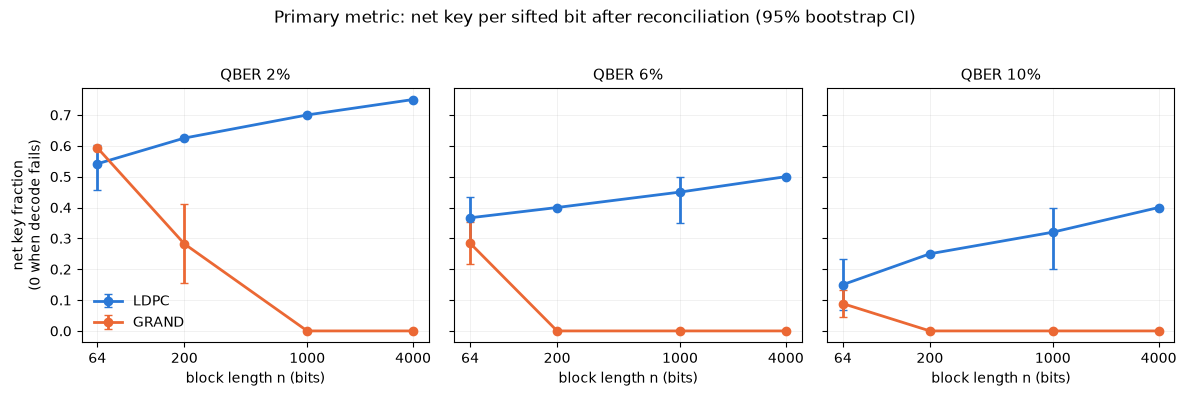

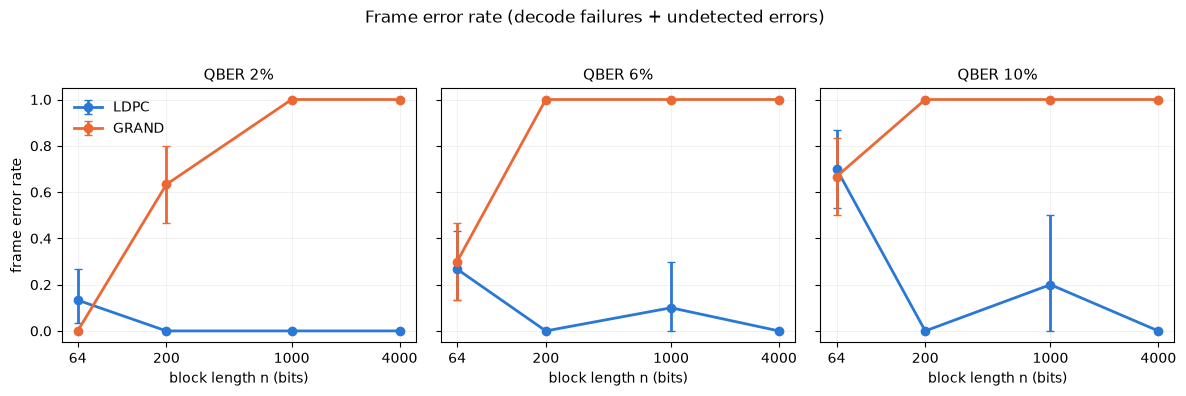

In [9]:
C_LDPC, C_GRAND, C_TIE = "#2a78d6", "#eb6834", "#a8a7a2"

def panel_metric(metric, ylabel, title, fname):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
    for ax, lab in zip(axes, QLABELS):
        for meth, col in (("LDPC", C_LDPC), ("GRAND", C_GRAND)):
            sub = summary[(summary.qber_label == lab) & (summary.method == meth)].sort_values("n")
            vals = sub[metric].to_numpy(dtype=float)
            ci = np.array([boot_ci((1 - df[(df.qber_label == lab) & (df.n == nn) &
                                          (df.method == meth)].correct.to_numpy())
                                   if metric == "FER" else
                                   df[(df.qber_label == lab) & (df.n == nn) &
                                      (df.method == meth)].net_key_fraction.to_numpy())
                           for nn in sub.n])
            ax.errorbar(sub.n, vals, yerr=[np.maximum(vals - ci[:, 0], 0),
                                           np.maximum(ci[:, 1] - vals, 0)],
                        color=col, lw=2, marker="o", ms=6, capsize=3, label=meth)
        ax.set_xscale("log"); ax.set_xticks(list(TRIALS)); ax.set_xticklabels(list(TRIALS))
        ax.minorticks_off()
        ax.grid(alpha=0.25, lw=0.5); ax.set_title(f"QBER {lab}", fontsize=11)
        ax.set_xlabel("block length n (bits)")
    axes[0].set_ylabel(ylabel)
    axes[0].legend(frameon=False)
    fig.suptitle(title, y=1.03)
    fig.tight_layout(); fig.savefig(RESULTS / fname, dpi=150, bbox_inches="tight")

panel_metric("net_key", "net key fraction\n(0 when decode fails)",
             "Primary metric: net key per sifted bit after reconciliation (95% bootstrap CI)",
             "spike_net_key.png")
panel_metric("FER", "frame error rate",
             "Frame error rate (decode failures + undetected errors)", "spike_fer.png")

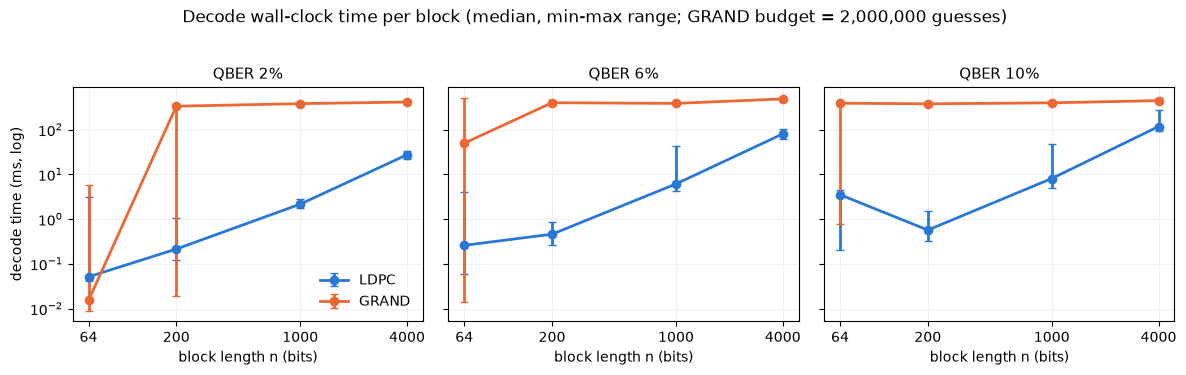

In [10]:
# Decode time (secondary axis of comparison) - median with min-max whiskers
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, lab in zip(axes, QLABELS):
    for meth, col in (("LDPC", C_LDPC), ("GRAND", C_GRAND)):
        sub = df[(df.qber_label == lab) & (df.method == meth)]
        g = sub.groupby("n").time_s
        med, mn, mx = g.median() * 1000, g.min() * 1000, g.max() * 1000
        ax.errorbar(med.index, med, yerr=[med - mn, mx - med],
                    color=col, lw=2, marker="o", ms=6, capsize=3, label=meth)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(list(TRIALS)); ax.set_xticklabels(list(TRIALS)); ax.minorticks_off()
    ax.grid(alpha=0.25, lw=0.5, which="both"); ax.set_title(f"QBER {lab}", fontsize=11)
    ax.set_xlabel("block length n (bits)")
axes[0].set_ylabel("decode time (ms, log)")
axes[0].legend(frameon=False)
fig.suptitle("Decode wall-clock time per block (median, min-max range; "
             f"GRAND budget = {GRAND_BUDGET:,} guesses)", y=1.03)
fig.tight_layout(); fig.savefig(RESULTS / "spike_time.png", dpi=150, bbox_inches="tight")

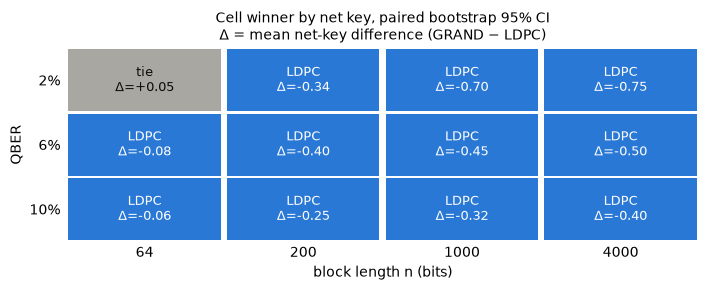

In [11]:
# Winner map (pre-registered rule)
fig, ax = plt.subplots(figsize=(7.2, 3.0))
colmap = {"LDPC": C_LDPC, "GRAND": C_GRAND, "tie": C_TIE}
ns = list(TRIALS)
for i, lab in enumerate(QLABELS):
    for j, n in enumerate(ns):
        row = verd[(verd.qber_label == lab) & (verd.n == n)].iloc[0]
        ax.add_patch(plt.Rectangle((j + 0.02, i + 0.02), 0.96, 0.96,
                                   color=colmap[row.winner], lw=0))
        ax.text(j + 0.5, i + 0.5, f"{row.winner}\nΔ={row.diff_mean:+.2f}",
                ha="center", va="center", fontsize=9,
                color="white" if row.winner != "tie" else "#0b0b0b")
ax.set_xlim(0, len(ns)); ax.set_ylim(0, len(QLABELS)); ax.invert_yaxis()
ax.set_xticks([j + 0.5 for j in range(len(ns))]); ax.set_xticklabels(ns)
ax.set_yticks([i + 0.5 for i in range(len(QLABELS))]); ax.set_yticklabels(QLABELS)
ax.set_xlabel("block length n (bits)"); ax.set_ylabel("QBER")
ax.set_title("Cell winner by net key, paired bootstrap 95% CI\n"
             "Δ = mean net-key difference (GRAND − LDPC)", fontsize=10)
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0)
fig.tight_layout(); fig.savefig(RESULTS / "spike_winner_map.png", dpi=150, bbox_inches="tight")

## 6. Spike verdict

**There is no crossover inside the requested grid (200–4000 bits × 2–10 % QBER): rate-adaptive
LDPC wins every one of those cells decisively.** GRAND's guess budget (2×10⁶) is exhausted the
moment the expected error count n·p exceeds ≈ 4–5, and it then fails 100 % of blocks while LDPC
decodes essentially everything at n ≥ 1000 (FER 0–20 %, mostly 0).

**The interesting signal is at the extreme short-block corner.** At n = 64, QBER 2 % the verdict
flips to a statistical tie *trending GRAND* (mean net-key Δ = +0.05, 95 % CI [−0.01, +0.14]):
GRAND decoded 30/30 blocks with zero failures and ~0.02 ms median decode time, while short-block
LDPC struggled (FER 13 %, plus **one undetected error** — BP converged to a wrong coset, exactly
the event a verification hash must catch in deployment). So the LDPC-vs-GRAND boundary is real
but lives at n ≲ 100 and low QBER — *below* the block lengths originally proposed.

**A second, subtler observation worth keeping:** GRAND's leakage rule is near-optimal at every
n (e.g. syndrome rate 0.152 at n = 4000, 2 % QBER — efficiency f ≈ 1.08 vs the Shannon limit
h₂(0.02) ≈ 0.141), but it cannot *decode* there. LDPC decodes everywhere but pays a large
leakage overhead at low QBER (0.25 at the same cell, f ≈ 1.77, partly from our coarse rate
ladder). The trade is structural: GRAND buys optimal leakage with exponential search;
LDPC buys polynomial decoding with leakage inefficiency.

**Trustworthiness flags reviewed:**
- GRAND's 100 % failure at n ≥ 1000 is deterministic budget exhaustion, not noise — the
  zero-width CIs there are expected, not suspicious.
- Pool QBER estimates p̂ landed within 0.3 pp of ground truth, so rate adaptation was not
  handicapped by estimation error.
- LDPC's FER 0 at (n = 4000, 10 %) is consistent with its calibrated threshold (rate-0.6 code
  usable to p ≈ 0.103) — near-threshold operation, plausibly lucky at 10 trials; worth more
  trials if this cell ever matters.
- Both methods at n = 64, QBER 10 % are effectively unusable (FER ≥ 67 %) — that corner has no
  winner worth claiming.

**Proposed stage 3 (pending decision):** zoom into the short-block corner — n ∈ {16…128} ×
QBER {1–4 %} with more trials — to locate the viability boundary precisely, plus a GRAND
budget-sensitivity sweep to show how the boundary moves with compute. That would turn the spike's
hint into the paper's quantitative claim ("GRAND is preferable below n ≈ X at QBER ≤ Y given
budget B; the boundary tracks n·p ≈ const(B)").